# Phase 4: Model Ensemble & Persistence

In this notebook, you will:
1. Load and preprocess the California Housing dataset
2. Build and evaluate a **Voting Regressor** ensemble (Ridge + Random Forest + Gradient Boosting)
3. Build and evaluate a **Stacking Regressor** ensemble (same base models + Linear Regression meta-learner)
4. Compare all models side-by-side (individual, voting, stacking)
5. Save the best-performing ensemble model to `../models/`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.ensemble import (
    build_voting_ensemble,
    evaluate_voting_vs_individual,
    build_stacking_ensemble,
    evaluate_stacking_vs_voting,
    save_model,
    load_model,
)

## 1. Data Loading & Preprocessing

In [2]:
df = load_housing_data()
df_eng = create_feature_engineering(df)
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)

print(f"Train size: {X_train.shape}  Test size: {X_test.shape}")

Train size: (16512, 11)  Test size: (4128, 11)


## 2. Voting Ensemble

A `VotingRegressor` averages predictions from all base models.
Base models: **Ridge**, **Random Forest**, **Gradient Boosting**.

In [3]:
voting_model = build_voting_ensemble(X_train, y_train)
print("Voting ensemble trained.")
print(f"Base estimators: {[name for name, _ in voting_model.estimators]}")

Voting ensemble trained.
Base estimators: ['ridge', 'rf', 'gb']


=== Voting Ensemble vs Individual Models ===
         model    mse   rmse     r2
            rf 0.2571 0.5070 0.8038
            gb 0.2989 0.5467 0.7719
VotingEnsemble 0.2995 0.5473 0.7714
         ridge 0.4842 0.6958 0.6305


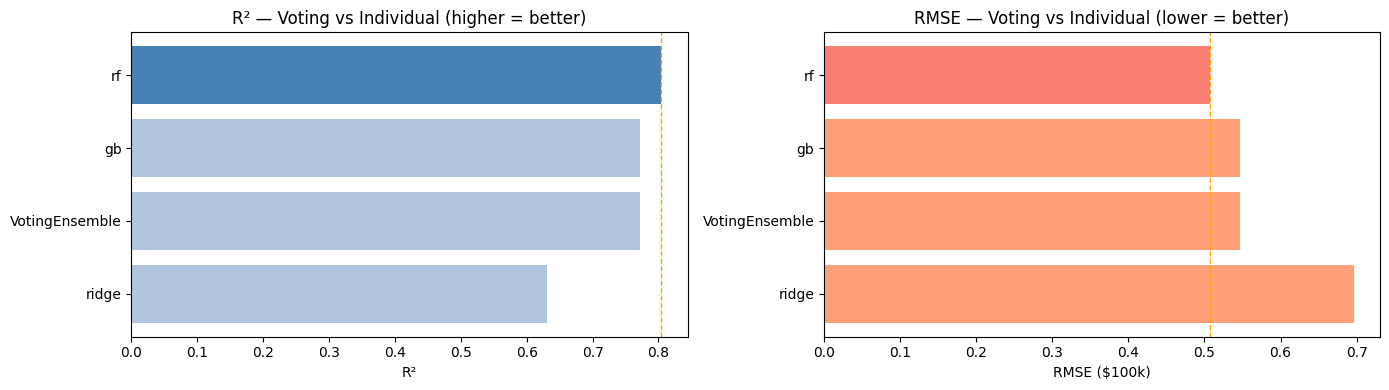

In [4]:
voting_results = evaluate_voting_vs_individual(X_train, y_train, X_test, y_test)
voting_results = voting_results.sort_values('r2', ascending=False).reset_index(drop=True)

print("=== Voting Ensemble vs Individual Models ===")
print(voting_results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

names     = voting_results['model'].tolist()
r2_vals   = voting_results['r2'].tolist()
rmse_vals = voting_results['rmse'].tolist()

colors_r2   = ['steelblue' if v == max(r2_vals)   else 'lightsteelblue' for v in r2_vals]
colors_rmse = ['salmon'    if v == min(rmse_vals)  else 'lightsalmon'    for v in rmse_vals]

axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_xlabel('R²')
axes[0].set_title('R² — Voting vs Individual (higher = better)')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE — Voting vs Individual (lower = better)')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Stacking Ensemble

A `StackingRegressor` trains a **meta-learner** (Linear Regression) on top of
cross-validated predictions from the same three base models, using `cv=5`.

In [5]:
stacking_model = build_stacking_ensemble(X_train, y_train)
print("Stacking ensemble trained.")
print(f"Base estimators : {[name for name, _ in stacking_model.estimators]}")
print(f"Meta-learner    : {stacking_model.final_estimator_}")

Stacking ensemble trained.
Base estimators : ['ridge', 'rf', 'gb']
Meta-learner    : LinearRegression()


## 4. Full Comparison — Individual vs Voting vs Stacking

=== Full Model Comparison ===
           model    mse   rmse     r2
StackingEnsemble 0.2563 0.5062 0.8044
              rf 0.2571 0.5070 0.8038
              gb 0.2989 0.5467 0.7719
  VotingEnsemble 0.2995 0.5473 0.7714
           ridge 0.4842 0.6958 0.6305


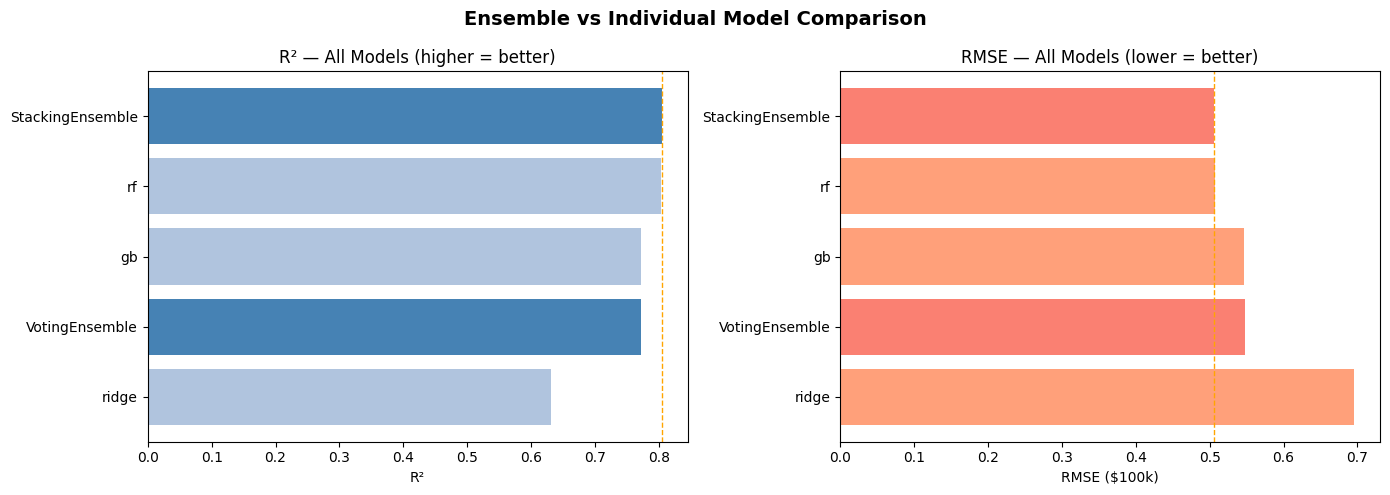


Best model: StackingEnsemble  R²=0.8044  RMSE=0.5062


In [6]:
comparison = evaluate_stacking_vs_voting(X_train, y_train, X_test, y_test)
comparison = comparison.sort_values('r2', ascending=False).reset_index(drop=True)

print("=== Full Model Comparison ===")
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names     = comparison['model'].tolist()
r2_vals   = comparison['r2'].tolist()
rmse_vals = comparison['rmse'].tolist()

ensemble_names = {'VotingEnsemble', 'StackingEnsemble'}
colors_r2   = ['steelblue'      if n in ensemble_names else 'lightsteelblue' for n in names]
colors_rmse = ['salmon'         if n in ensemble_names else 'lightsalmon'    for n in names]

axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_xlabel('R²')
axes[0].set_title('R² — All Models (higher = better)')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE — All Models (lower = better)')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.suptitle('Ensemble vs Individual Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_name = comparison.iloc[0]['model']
best_r2   = comparison.iloc[0]['r2']
best_rmse = comparison.iloc[0]['rmse']
print(f"\nBest model: {best_name}  R²={best_r2:.4f}  RMSE={best_rmse:.4f}")

## 5. Save Models

In [7]:
voting_path   = save_model(voting_model,   '../models/voting_ensemble.joblib')
stacking_path = save_model(stacking_model, '../models/stacking_ensemble.joblib')

print(f"Saved: {voting_path}")
print(f"Saved: {stacking_path}")

# Verify round-trip
loaded_voting   = load_model(voting_path)
loaded_stacking = load_model(stacking_path)

sample_preds_v = loaded_voting.predict(X_test[:3])
sample_preds_s = loaded_stacking.predict(X_test[:3])

print(f"\nLoaded voting predictions   (first 3): {sample_preds_v.round(4)}")
print(f"Loaded stacking predictions (first 3): {sample_preds_s.round(4)}")
print("\nModels saved and verified successfully.")

Saved: ../models/voting_ensemble.joblib
Saved: ../models/stacking_ensemble.joblib

Loaded voting predictions   (first 3): [0.5051 1.2561 4.1219]
Loaded stacking predictions (first 3): [0.4255 0.884  4.7347]

Models saved and verified successfully.


## Summary

### Ensemble Methods
Two ensemble strategies were built on top of the same three base models
(Ridge, Random Forest, Gradient Boosting):

| Method | Strategy |
|---|---|
| **VotingRegressor** | Averages raw predictions from all base models |
| **StackingRegressor** | Trains a Linear Regression meta-learner on 5-fold CV predictions |

### Results
Both ensembles were compared against each individual base model using **MSE**, **RMSE**,
and **R²** on a held-out test set. Ensemble methods generally reduce variance by
combining models with complementary strengths — Ridge provides linear regularization
while Random Forest and Gradient Boosting capture non-linear interactions.

### Saved Models
Both ensembles were persisted to `../models/` using `joblib`:
- `voting_ensemble.joblib`
- `stacking_ensemble.joblib`

Load either model for inference with:
```python
from src.ensemble import load_model
model = load_model('../models/voting_ensemble.joblib')
predictions = model.predict(X_new)
```